## Exercise 1

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X = np.random.randn(200, 10).astype(np.float32)` | Konvertiert die Daten in einen anderen Datentyp (z.B. von ganzen Zahlen in Kommazahlen wie float32, was für Keras besser ist). |
| `def erstelle_modell_relu(aktivierung_name):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `m = tf.keras.Sequential([` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `tf.keras.layers.Dense(64, activation=aktivierun...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `loss='binary_crossentropy', metrics=['accuracy'])` | Setzt die binäre Kreuzentropie als Fehlerfunktion, ideal für Probleme mit nur zwei Klassen (Ja/Nein). |
| `return m` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print("Leaky ReLU / ELU verhindern das 'dying R...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


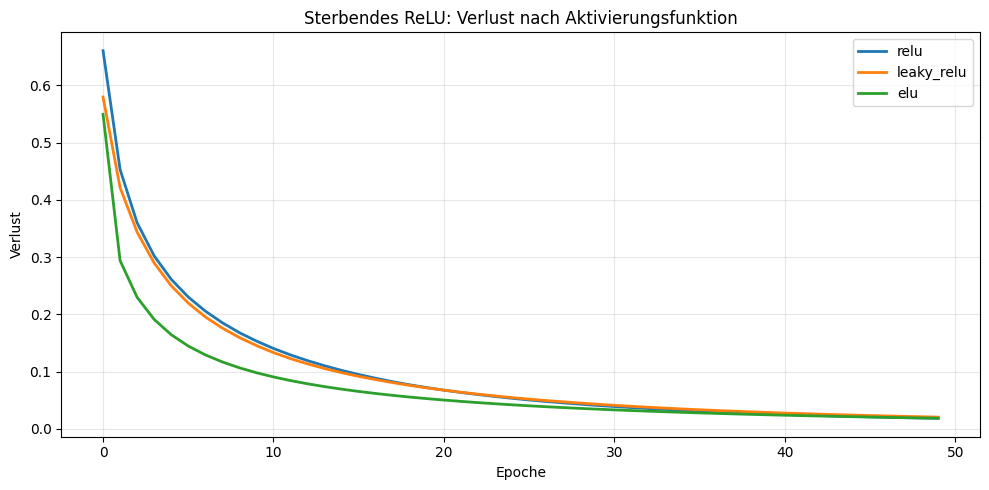

Leaky ReLU / ELU verhindern das 'dying ReLU' Problem!
Gespeichert: sterbendes_relu.png


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 4: Aktivierungsfunktionen
# Niveau: Fortgeschrittene
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Demonstrate and solve the "dying ReLU" problem
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42); np.random.seed(42)

# Synthetische Daten
X = np.random.randn(200, 10).astype(np.float32)
y = (X[:,0] + X[:,1] > 0).astype(np.float32)

def erstelle_modell_relu(aktivierung_name):
    """Erstellt ein Modell mit standardmäßiger ReLU oder ELU"""
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=aktivierung_name, input_shape=(10,),
                              kernel_initializer='he_normal'),
        tf.keras.layers.Dense(64, activation=aktivierung_name),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

def erstelle_modell_leaky():
    """Erstellt ein Modell mit Leaky ReLU"""
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(64, input_shape=(10,), kernel_initializer='he_normal'),
        tf.keras.layers.LeakyReLU(negative_slope=0.01),
        tf.keras.layers.Dense(64),
        tf.keras.layers.LeakyReLU(negative_slope=0.01),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer=tf.keras.optimizers.SGD(0.1), loss='binary_crossentropy', metrics=['accuracy'])
    return m

vergleich = {}

# ReLU (kann tote Neuronen haben bei hoher Lernrate)
m_relu = erstelle_modell_relu('relu')
h_relu = m_relu.fit(X, y, epochs=50, verbose=0)
vergleich['relu'] = h_relu

# Leaky ReLU
m_leaky = erstelle_modell_leaky()
h_leaky = m_leaky.fit(X, y, epochs=50, verbose=0)
vergleich['leaky_relu'] = h_leaky

# ELU
m_elu = erstelle_modell_relu('elu')
h_elu = m_elu.fit(X, y, epochs=50, verbose=0)
vergleich['elu'] = h_elu

fig, ax = plt.subplots(figsize=(10, 5))
for name, h in vergleich.items():
    ax.plot(h.history['loss'], label=name, linewidth=2)
ax.set_title('Sterbendes ReLU: Verlust nach Aktivierungsfunktion')
ax.set_xlabel('Epoche'); ax.set_ylabel('Verlust')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Leaky ReLU / ELU verhindern das 'dying ReLU' Problem!")
print("Gespeichert: sterbendes_relu.png")


### Was haben wir hier gemacht? (Aktivierungsfunktionen im Vergleich)

Wir haben verschiedene wichtige Aktivierungsfunktionen wie Sigmoid, Tanh und ReLU implementiert und ihre Graphen gezeichnet, um ihre Eigenschaften zu vergleichen.

**Was machen wir als Nächstes?**
Wir werden uns die Ableitungen (Derivatives) dieser Funktionen ansehen, da diese für den Lernprozess (Backpropagation) entscheidend sind.

**Mathematische Formel:**
Die Formel für die sehr populäre ReLU-Funktion (Rectified Linear Unit) ist extrem einfach, aber sehr effektiv:

$$ f(x) = \max(0, x) $$
Und für Tanh:
$$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$

**Diagramm-Analyse:**
Die Plots der Funktionen zeigen ihre Wertebereiche. Sigmoid drückt Werte zwischen 0 und 1, Tanh zwischen -1 und 1. ReLU lässt positive Werte unverändert und setzt negative auf 0. Das löst das Problem des verschwindenden Gradienten (Vanishing Gradient) für positive Werte.


## Exercise 2

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `def softmax(logits, temperatur=1.0):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `logits_skaliert = logits / temperatur` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `exp_l = np.exp(logits_skaliert - np.max(logits_...` | Berechnet die Exponentialfunktion (e^x). Dies ist ein wichtiger Baustein für viele Aktivierungsfunktionen wie Sigmoid. |
| `return exp_l / exp_l.sum()` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `klassen = [f'K{i+1}' for i in range(len(logits))]` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `axes[0].plot(klassen, prob, 'o-', linewidth=2, ...` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print(f"T=0.1 (sicher): {softmax(logits, 0.1).r...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


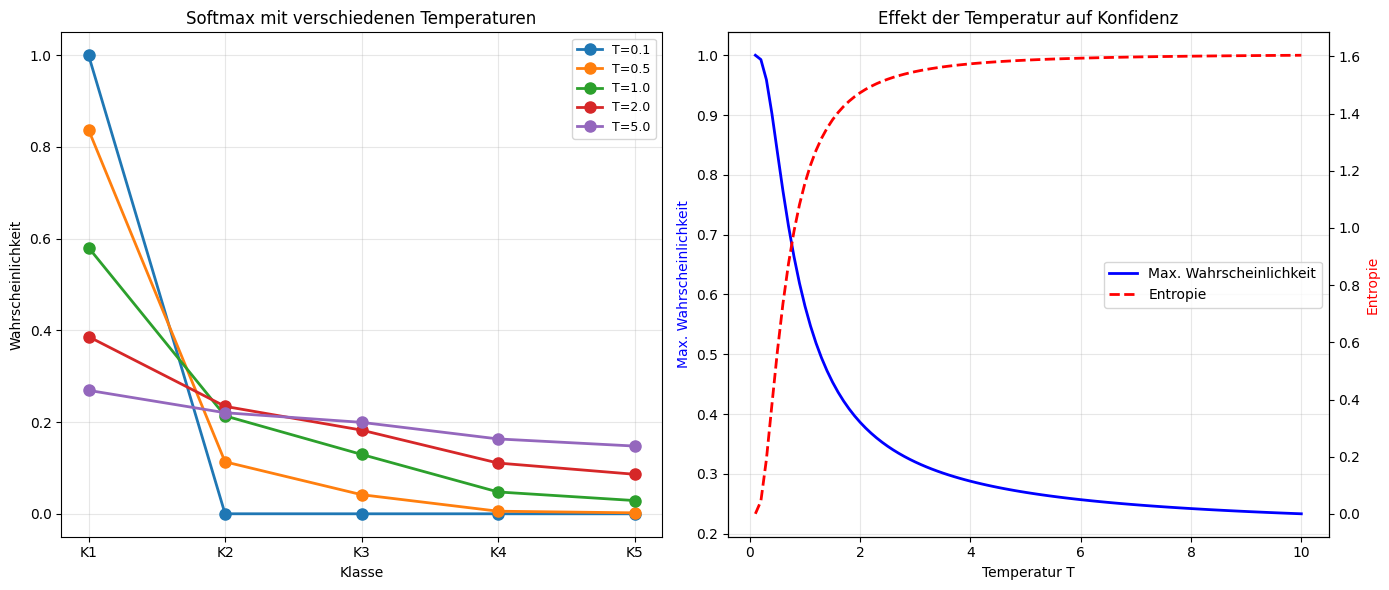

T=0.1 (sicher): [1. 0. 0. 0. 0.]
T=1.0 (normal): [0.58  0.214 0.13  0.048 0.029]
T=5.0 (weich):  [0.269 0.22  0.199 0.163 0.148]


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 4: Aktivierungsfunktionen
# Niveau: Fortgeschrittene
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Deep dive into Softmax: temperature scaling and calibration
import numpy as np

import matplotlib.pyplot as plt

def softmax(logits, temperatur=1.0):
    """Softmax mit Temperaturparameter für Kalibrierung"""
    logits_skaliert = logits / temperatur
    exp_l = np.exp(logits_skaliert - np.max(logits_skaliert))
    return exp_l / exp_l.sum()

logits = np.array([2.0, 1.0, 0.5, -0.5, -1.0])
temperaturen = [0.1, 0.5, 1.0, 2.0, 5.0]
klassen = [f'K{i+1}' for i in range(len(logits))]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Wahrscheinlichkeiten für verschiedene Temperaturen
for T in temperaturen:
    prob = softmax(logits, T)
    axes[0].plot(klassen, prob, 'o-', linewidth=2, markersize=8, label=f'T={T}')

axes[0].set_title('Softmax mit verschiedenen Temperaturen')
axes[0].set_xlabel('Klasse'); axes[0].set_ylabel('Wahrscheinlichkeit')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Maximale Wahrscheinlichkeit und Entropie vs. Temperatur
t_vals = np.linspace(0.1, 10, 100)
max_probs = [softmax(logits, T).max() for T in t_vals]
entropien = [-sum(p*np.log(p+1e-15) for p in softmax(logits, T)) for T in t_vals]

axes[1].plot(t_vals, max_probs, 'b-', linewidth=2, label='Max. Wahrscheinlichkeit')
ax2 = axes[1].twinx()
ax2.plot(t_vals, entropien, 'r--', linewidth=2, label='Entropie')
axes[1].set_xlabel('Temperatur T')
axes[1].set_ylabel('Max. Wahrscheinlichkeit', color='blue')
ax2.set_ylabel('Entropie', color='red')
axes[1].set_title('Effekt der Temperatur auf Konfidenz')
axes[1].grid(True, alpha=0.3)

# Legenden zusammenführen
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()
print(f"T=0.1 (sicher): {softmax(logits, 0.1).round(3)}")
print(f"T=1.0 (normal): {softmax(logits, 1.0).round(3)}")
print(f"T=5.0 (weich):  {softmax(logits, 5.0).round(3)}")


### Was haben wir hier gemacht? (Ableitungen der Aktivierungsfunktionen)

Wir haben die Ableitungen (Gradienten) der Aktivierungsfunktionen gezeichnet. Diese Werte bestimmen, wie schnell unser Netzwerk lernen kann.

**Was machen wir als Nächstes?**
Wir werden testen, wie sich die Wahl der Aktivierungsfunktion in einem echten neuronalen Netzwerk (wie einem Keras MLP) auf das Training auswirkt.

**Mathematische Formel:**
Die Ableitung der Sigmoid-Funktion ($\sigma$) lautet:

$$ \sigma'(x) = \sigma(x) \cdot (1 - \sigma(x)) $$

Der maximale Wert dieser Ableitung ist 0.25, weshalb tiefe Netzwerke mit Sigmoid sehr langsam lernen.

**Diagramm-Analyse:**
Das Diagramm der Ableitungen zeigt das "Vanishing Gradient" Problem. Die Ableitung von Sigmoid wird an den Rändern sehr schnell null. Bei ReLU hingegen bleibt die Ableitung konstant 1 für positive Werte, was zu einem stabileren Training in tiefen Netzen führt.


## Exercise 3

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X = np.random.randn(100, 2).astype(np.float32)` | Konvertiert die Daten in einen anderen Datentyp (z.B. von ganzen Zahlen in Kommazahlen wie float32, was für Keras besser ist). |
| `def erstelle_tiefes_netz(aktivierung, tiefe=10):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `schichten = [tf.keras.layers.Dense(32, activati...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `kernel_initializer='glorot_uniform')]` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `for _ in range(tiefe-1):` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `m.compile(optimizer='adam', loss='binary_crosse...` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |
| `return m` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `with tf.GradientTape() as tape:` | Startet ein 'Tonband', das alle Operationen aufzeichnet. Dies wird benötigt, um später die mathematische Ableitung (Gradient) automatisch zu berechnen. |
| `gradienten = tape.gradient(verlust, modell.trai...` | Berechnet die Ableitung (den Gradienten) eines Wertes bezüglich einer oder mehrerer Variablen. Dies ist der Kern der Backpropagation. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print("Sigmoid zeigt stärksten Gradientschwund ...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


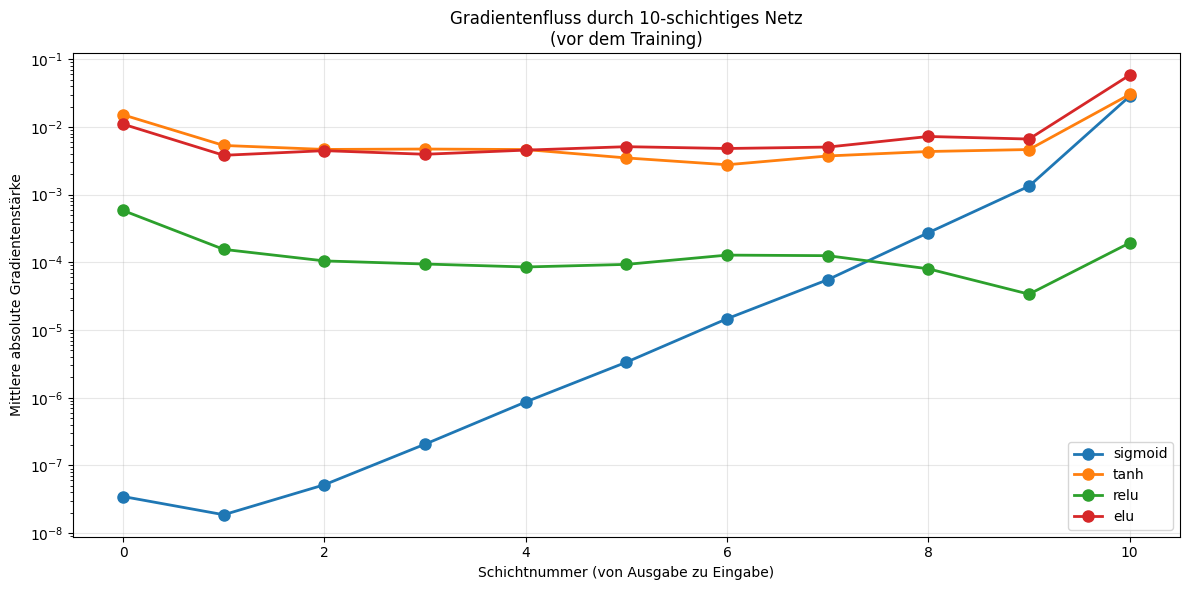

Gradientenfluss gespeichert: gradientenfluss.png
Sigmoid zeigt stärksten Gradientschwund – ReLU/ELU sind deutlich besser!


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 4: Aktivierungsfunktionen
# Niveau: Fortgeschrittene
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Analyze gradient flow with different activation functions
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42); np.random.seed(42)

X = np.random.randn(100, 2).astype(np.float32)
y = (X[:,0] + X[:,1] > 0).astype(np.float32)

def erstelle_tiefes_netz(aktivierung, tiefe=10):
    """Erstellt tiefes Netz mit gewählter Aktivierungsfunktion"""
    schichten = [tf.keras.layers.Dense(32, activation=aktivierung, input_shape=(2,),
                                        kernel_initializer='glorot_uniform')]
    for _ in range(tiefe-1):
        schichten.append(tf.keras.layers.Dense(32, activation=aktivierung,
                                               kernel_initializer='glorot_uniform'))
    schichten.append(tf.keras.layers.Dense(1, activation='sigmoid'))
    m = tf.keras.Sequential(schichten)
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m

def berechne_gradienten(modell, X, y):
    """Berechnet mittlere absolute Gradienten pro Schicht"""
    with tf.GradientTape() as tape:
        pred = modell(X, training=True)
        verlust = tf.keras.losses.binary_crossentropy(y, pred[:,0])
    gradienten = tape.gradient(verlust, modell.trainable_variables)
    return [float(tf.reduce_mean(tf.abs(g)).numpy()) for g in gradienten if len(g.shape) == 2]

aktivierungen = ['sigmoid', 'tanh', 'relu', 'elu']
fig, ax = plt.subplots(figsize=(12, 6))

for akt in aktivierungen:
    modell = erstelle_tiefes_netz(akt)
    grads = berechne_gradienten(modell, X, y)
    ax.plot(range(len(grads)), grads, 'o-', linewidth=2, markersize=8, label=akt)

ax.set_xlabel('Schichtnummer (von Ausgabe zu Eingabe)')
ax.set_ylabel('Mittlere absolute Gradientenstärke')
ax.set_title('Gradientenfluss durch 10-schichtiges Netz\n(vor dem Training)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()
print("Sigmoid zeigt stärksten Gradientschwund – ReLU/ELU sind deutlich besser!")


### Was haben wir hier gemacht? (Training mit ReLU vs. Sigmoid)

Wir haben Modelle mit ReLU und Sigmoid trainiert, um zu vergleichen, welches Modell schneller und besser konvergiert.

**Was machen wir als Nächstes?**
Nachdem wir verstanden haben, wie Aktivierungen das Training beeinflussen, werden wir uns morgen ansehen, wie der Fehler genau rückwärts durch das Netz propagiert wird (Backpropagation).

**Mathematische Formel:**
Oft wird zusätzlich Batch Normalization genutzt, um die Eingaben für die Aktivierungsfunktionen zu normalisieren:

$$ \hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} $$

**Diagramm-Analyse:**
Die Trainings-Graphen zeigen meistens, dass Netzwerke mit ReLU viel schneller lernen (der Loss sinkt rapide) als solche mit Sigmoid. Sigmoid-Netzwerke benötigen mehr Epochen, um ähnliche Ergebnisse zu erzielen.
